<a href="https://colab.research.google.com/github/nwilliamsanalytics/content-investment-roi/blob/main/US_vs_Foreign_ROI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ROI ANALYSIS**

Do films with production outside the US create more value for the producing studio than films produced inside the US?

In [6]:
#IMPORT packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
#IMPORT dataset

df = pd.read_csv('FCST_v_ACTv2.csv')
df.head()

,Title,First_Genre,Genres,Production_Budget,Forecast_Worldwide,Forecast_Domestic,Forecast_Foreign,Actuals_Worldwide,Actuals_Domestic,Actuals_Domestic_%,Actuals_Foreign,Actuals_Foreign_%,Release_Year,Distributor,Rating_Score,Vote_Count,Original_Language,Production_Countries
0,Inside Out 2,Animation,"Animation, Adventure, Comedy, Family","119,868,566.10","$1,628,220,389.63","$613,801,382.36","1,014,419,007.27","$1,698,772,985.00","$652,980,194.00",38.44%,"$1,045,792,791.00",61.56%,2024,Walt Disney Studios Motion Pictures,7.566,5141,en,United States of America
1,Deadpool & Wolverine,Action,"Action, Comedy, Science Fiction","94,469,427.95","$1,184,518,085.47","$560,336,355.04","624,181,730.43","$1,338,073,645.00","$636,745,858.00",47.59%,"$701,327,787.00",52.41%,2024,Walt Disney Studios Motion Pictures,7.700,6120,en,United States of America
2,Despicable Me 4,Animation,"Animation, Family, Comedy, Science Fiction","125,907,541.50","$1,043,239,983.27","$368,224,289.10","675,015,694.17","$969,126,452.00","$361,004,205.00",37.25%,"$608,122,247.00",62.75%,2024,Universal Pictures,7.100,2354,en,United States of America
3,Moana 2,Animation,"Animation, Adventure, Family, Comedy","160,921,194.30","$821,709,380.55","$340,007,380.55","481,702,000.00","$896,608,683.00","$400,008,683.00",44.61%,"$496,600,000.00",55.39%,2024,Walt Disney Studios Motion Pictures,6.955,685,en,"Canada, United States of America"
4,Dune: Part Two,Science Fiction,"Science Fiction, Adventure","90,633,865.01","$717,447,470.84","$276,501,470.84","440,946,000.00","$714,444,358.00","$282,144,358.00",39.49%,"$432,300,000.00",60.51%,2024,Warner Bros.,8.200,5866,en,United States of America


In [14]:
#SHOW data types

df.dtypes

,0
Title,object
First_Genre,object
Genres,object
Production_Budget,float64
Forecast_Worldwide,float64
Forecast_Domestic,float64
Forecast_Foreign,float64
Actuals_Worldwide,float64
Actuals_Domestic,float64
Actuals_Domestic_%,object


In [15]:
#CLEAN data - change data types for numeric columns

cols_to_clean = [
    'Production_Budget',
    'Forecast_Worldwide',
    'Forecast_Domestic',
    'Forecast_Foreign',
    'Actuals_Worldwide',
    'Actuals_Domestic',
    'Actuals_Foreign'
]

for col in cols_to_clean:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[cols_to_clean].dtypes

,0
Production_Budget,float64
Forecast_Worldwide,float64
Forecast_Domestic,float64
Forecast_Foreign,float64
Actuals_Worldwide,float64
Actuals_Domestic,float64
Actuals_Foreign,float64


In [16]:
#CHECK data types

df.dtypes

,0
Title,object
First_Genre,object
Genres,object
Production_Budget,float64
Forecast_Worldwide,float64
Forecast_Domestic,float64
Forecast_Foreign,float64
Actuals_Worldwide,float64
Actuals_Domestic,float64
Actuals_Domestic_%,object


In [6]:
#DEFINE value
#ROI = (Actuals - Budget)/ Budget
#Profit proxy = Actuals - Budget

In [17]:
#CREATE ROI columm

df['ROI'] = (df['Actuals_Worldwide'] - df['Production_Budget']) / df['Production_Budget']

In [18]:
#CHECK ROI calc

df[['Title', 'Production_Budget', 'Actuals_Worldwide', 'ROI']].head()

,Title,Production_Budget,Actuals_Worldwide,ROI
0,Inside Out 2,1.198686e+08,1.698773e+09,13.171964
1,Deadpool & Wolverine,9.446943e+07,1.338074e+09,13.164092
2,Despicable Me 4,1.259075e+08,9.691265e+08,6.697128
3,Moana 2,1.609212e+08,8.966087e+08,4.571725
4,Dune: Part Two,9.063387e+07,7.144444e+08,6.882753


In [19]:
#CREATE US vs. International Flag

df['Production_Type'] = df['Production_Countries'].apply(
    lambda x: 'US' if 'United States' in str(x) else 'International'
)

df[['Production_Countries', 'Production_Type']].head()

,Production_Countries,Production_Type
0,United States of America,US
1,United States of America,US
2,United States of America,US
3,"Canada, United States of America",US
4,United States of America,US


In [23]:
#Correct formula - US should be US, anything else should be International
    #Note:  I treated co-productions as international to isolate purely domestic production economics versus globally structured financing.

df['Production_Type'] = df['Production_Countries'].apply(
    lambda x: 'US' if str(x).strip() == 'United States of America' else 'International'
)

df[['Production_Countries', 'Production_Type']].head()

,Production_Countries,Production_Type
0,United States of America,US
1,United States of America,US
2,United States of America,US
3,"Canada, United States of America",International
4,United States of America,US


In [24]:
#FIND mean of US vs. INT

df.groupby('Production_Type')['ROI'].agg(['mean', 'median', 'count']).round(2)

,mean,median,count
Production_Type,,,
International,0.43,-0.70,129
US,1.20,-0.21,165


**Observations:**

**Mean**
US-produced films seem to have more mean ROI (1.20) than internationally produced films (0.43).

**Median ROI**
Both medians are negative which means that most films lose money, there are a few films that pull up the average.

**CONCLUSION**
While US-produced films generate higher average returns, both US and international productions have negative median ROI, indicating that profitability is driven by a small number of high-performing outliers. However, US productions show stronger upside potential and less downside risk relative to international productions.

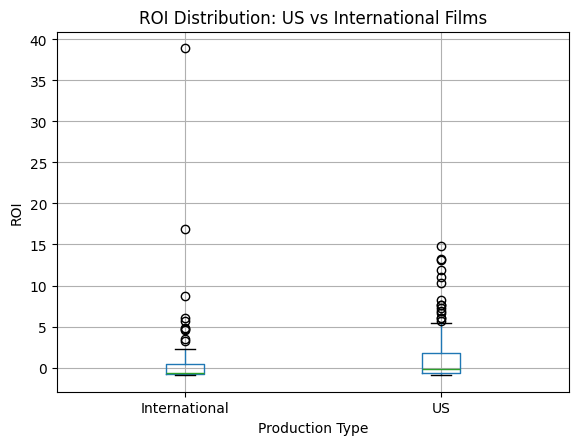

In [25]:
#VISUALIZATION

import matplotlib.pyplot as plt

df.boxplot(column='ROI', by='Production_Type')

plt.title('ROI Distribution: US vs International Films')
plt.suptitle('')
plt.xlabel('Production Type')
plt.ylabel('ROI')

plt.show()

In [26]:
#ADD ROI cap to correct for outliers skewing the viz

df_filtered = df[(df['ROI'] > -2) & (df['ROI'] < 5)]

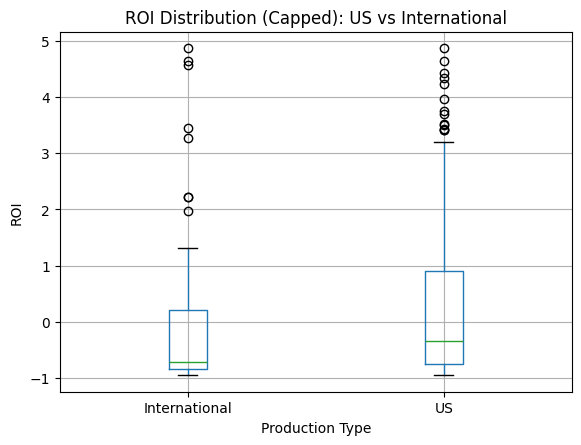

In [47]:
#REPLOT

import matplotlib.pyplot as plt

df_filtered.boxplot(column='ROI', by='Production_Type')

plt.title('ROI Distribution (Capped): US vs International')
plt.suptitle('')
plt.xlabel('Production Type')
plt.ylabel('ROI')

plt.show()

# **Interpreting the Box Plot**


**Box (Interquartile Range)**

The box represents the middle 50% of ROI values, with 25% of observations below and 25% above. The line inside the box indicates the median ROI.

Both US and internationally produced films have negative median ROI (green horizontal line in blue box), indicating that most films are unprofitable. However, US-produced films have a higher (less negative) median ROI, suggesting stronger typical performance.


**Whiskers**

The whiskers extend to the highest and lowest ROI values within 1.5× the interquartile range, representing the range of typical performance.

Points beyond the whiskers are outliers, highlighting that a small number of high-performing films drive overall returns.


__________________________________________________________



This distribution highlights the highly skewed nature of film returns, where overall profitability is driven by a small number of outsized successes.


In [28]:
#CREATE trend visual

roi_trend = df.groupby(['Release_Year', 'Production_Type'])['ROI'].mean().reset_index()

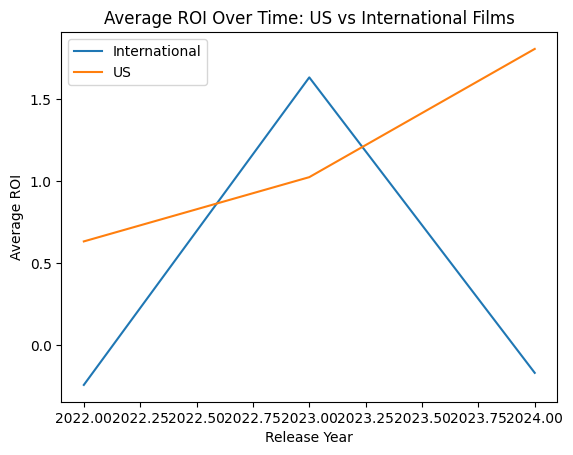

In [29]:

import matplotlib.pyplot as plt

for ptype in roi_trend['Production_Type'].unique():
    subset = roi_trend[roi_trend['Production_Type'] == ptype]
    plt.plot(subset['Release_Year'], subset['ROI'], label=ptype)

plt.title('Average ROI Over Time: US vs International Films')
plt.xlabel('Release Year')
plt.ylabel('Average ROI')
plt.legend()

plt.show()

In [31]:
#

studio_roi = df.groupby(['Distributor', 'Production_Type'])['ROI'].mean().reset_index()

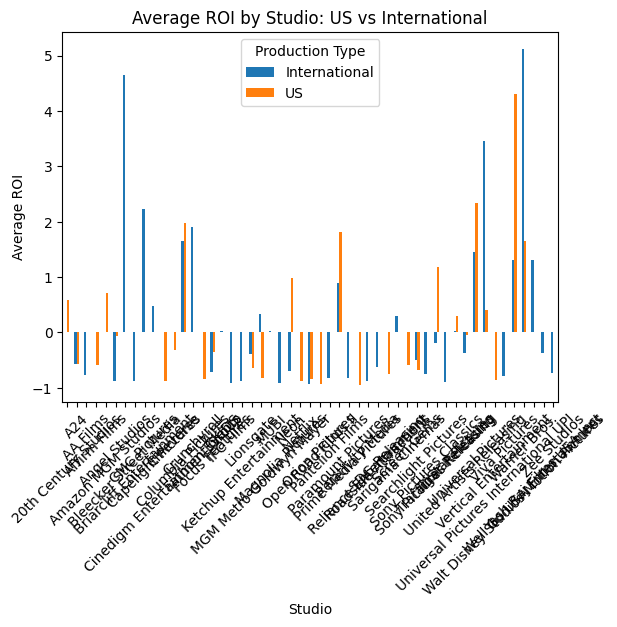

In [32]:
#PLOT chart by studio

import matplotlib.pyplot as plt

# Pivot for cleaner plotting
pivot = studio_roi.pivot(index='Distributor', columns='Production_Type', values='ROI')

pivot.plot(kind='bar')

plt.title('Average ROI by Studio: US vs International')
plt.xlabel('Studio')
plt.ylabel('Average ROI')
plt.xticks(rotation=45)
plt.legend(title='Production Type')

plt.show()

In [34]:
#FILTER for top studios

top_studios = df['Distributor'].value_counts().head(10).index

df_top = df[df['Distributor'].isin(top_studios)]

In [35]:
#RECALCULATE ROI by studio

studio_roi_top = df_top.groupby(['Distributor', 'Production_Type'])['ROI'].mean().reset_index()

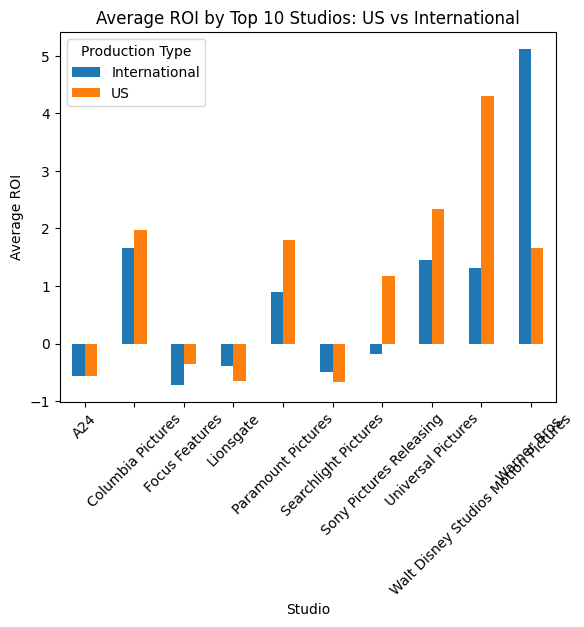

In [36]:
#REPLOT

pivot_top = studio_roi_top.pivot(index='Distributor', columns='Production_Type', values='ROI')

pivot_top.plot(kind='bar')

plt.title('Average ROI by Top 10 Studios: US vs International')
plt.xlabel('Studio')
plt.ylabel('Average ROI')
plt.xticks(rotation=45)
plt.legend(title='Production Type')

plt.show()

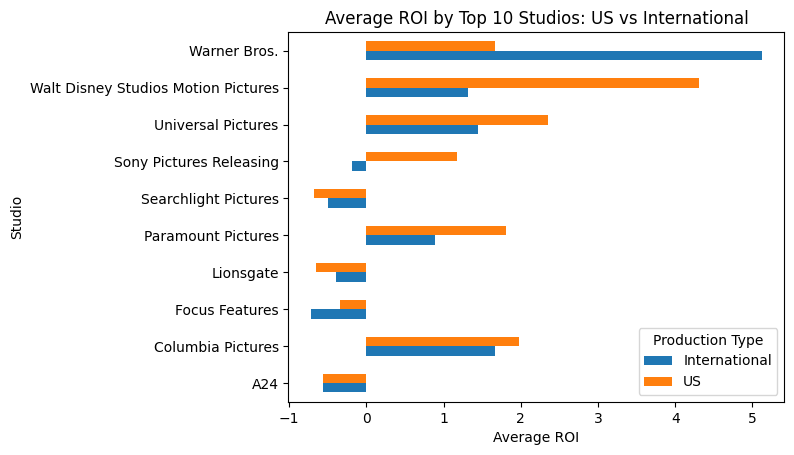

In [37]:
#FLIP axis for better display

pivot_top.plot(kind='barh')

plt.title('Average ROI by Top 10 Studios: US vs International')
plt.xlabel('Average ROI')
plt.ylabel('Studio')
plt.legend(title='Production Type')

plt.show()

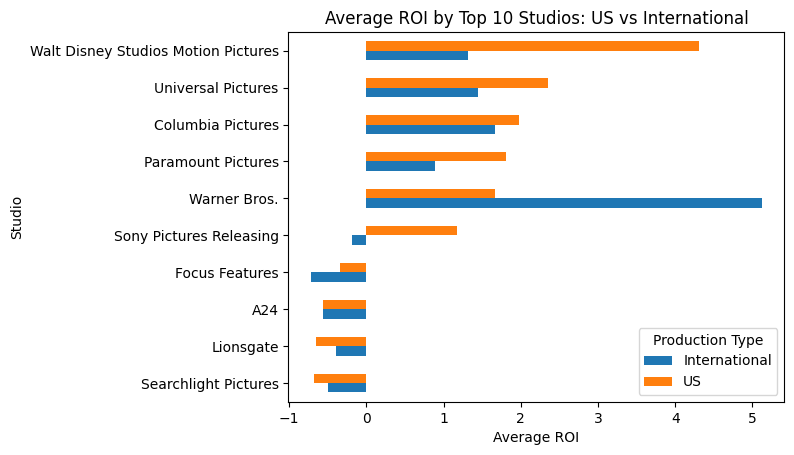

In [41]:
#SORT by ROI

# SORT
pivot_top = pivot_top.sort_values(by='US', ascending=True)

# PLOT (you were missing this)
pivot_top.plot(kind='barh')

# LABELS
plt.title('Average ROI by Top 10 Studios: US vs International')
plt.xlabel('Average ROI')
plt.ylabel('Studio')
plt.legend(title='Production Type')

plt.show()

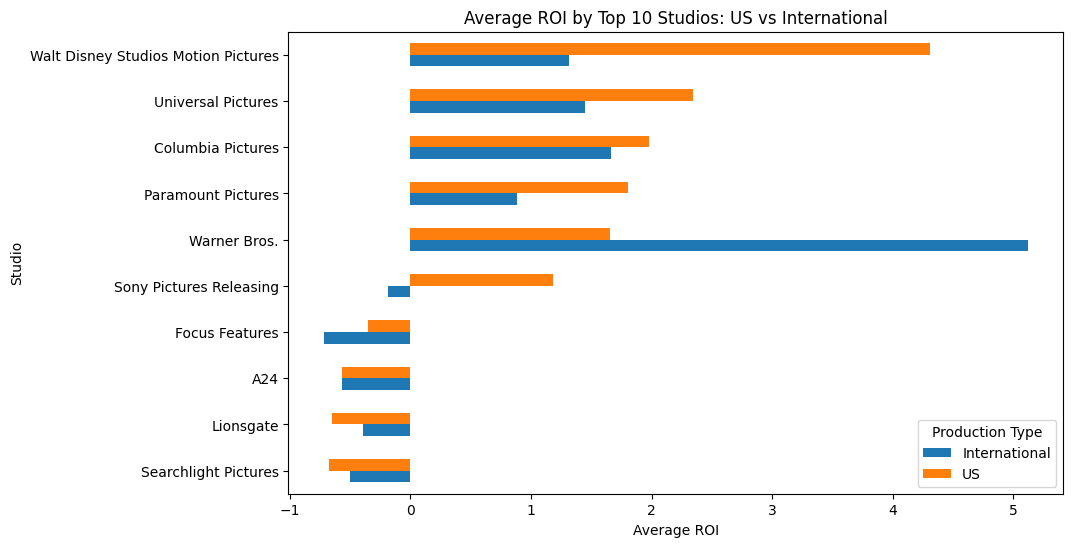

In [43]:
pivot_top.plot(kind='barh', figsize=(10,6))

# LABELS
plt.title('Average ROI by Top 10 Studios: US vs International')
plt.xlabel('Average ROI')
plt.ylabel('Studio')
plt.legend(title='Production Type')

plt.show()

# **Interpreting the Chart**



*   US-produced films generally deliver higher average ROI across major studios
*   Performance varies significantly by studio, with upside often driven by blockbuster releases
*   International productions show more limited upside and weaker average returns across most distributors
*   Results highlight the importance of studio strategy and portfolio composition in driving returns



**Note:**


*Warner Bros.* is a notable exception, where internationally produced films outperform US productions in average ROI. This may reflect a greater emphasis on international co-productions or globally oriented content strategy, though further analysis would be required to confirm production mix and investment patterns.

These results reinforce the hit-driven nature of film economics, where a small number of high-performing titles can materially impact overall returns.

*Budgets and forecast amounts are simulated and do not represent actual figures.*


In [44]:
#SAVE final dataset for visualization in Tableau

df.to_csv('film_roi_analysis.csv', index=False)

In [45]:
#EXPORT dataset as .csv file

from google.colab import files
files.download('film_roi_analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
#SAVE & EXPORT as excel file

df.to_excel('film_roi_analysis.xlsx', index=False)

files.download('film_roi_analysis.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>